# Ülke Sosyo-Ekonomik Gelişmişlik Kümeleme Analizi

Bu çalışma, `29-country_data.csv` veri seti üzerinde gelişmiş gözetimsiz öğrenme (Unsupervised Learning) tekniklerini uygulayarak dünyadaki ülkeleri sosyo-ekonomik ve sağlık göstergelerine göre segmente etmektedir.

### Analiz Kapsamı ve Yöntem:
1. **Keşifsel Veri Analizi (EDA)**: Değişkenlerin dağılımları ve ilişki matrisleri.
2. **Hiyerarşik Ağaç Analizi (Dendrogram)**: Doğal küme sayısının tespiti.
3. **Boyut İndirgeme (PCA) Etkisi**: 9 değişkenli orijinal uzay ile 3 bileşenli PCA uzayının kümeleme performansına etkisi.
4. **Çoklu Model Karşılaştırması**: K-Means, Agglomerative Clustering, GMM, DBSCAN ve HDBSCAN modellerinin değerlendirilmesi.
5. **Coğrafi Görselleştirme**: Ülke segmentasyonunun Plotly ile dünya haritası üzerinde incelenmesi.


## 1. Ortam Hazırlığı ve Kütüphaneler


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Görselleştirme teması
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

print("Analiz ortamı başarıyla kuruldu.")


Analiz ortamı başarıyla kuruldu.


## 2. Veri Yapısı ve İstatistiksel Özet


In [2]:
df = pd.read_csv("29-country_data.csv")
print(f"Gözlem Sayısı (Ülke): {df.shape[0]}, Öznitelik Sayısı: {df.shape[1]}")
df.head()


Gözlem Sayısı (Ülke): 167, Öznitelik Sayısı: 10


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Öznitelik Dağılımları (Distribution Plots)


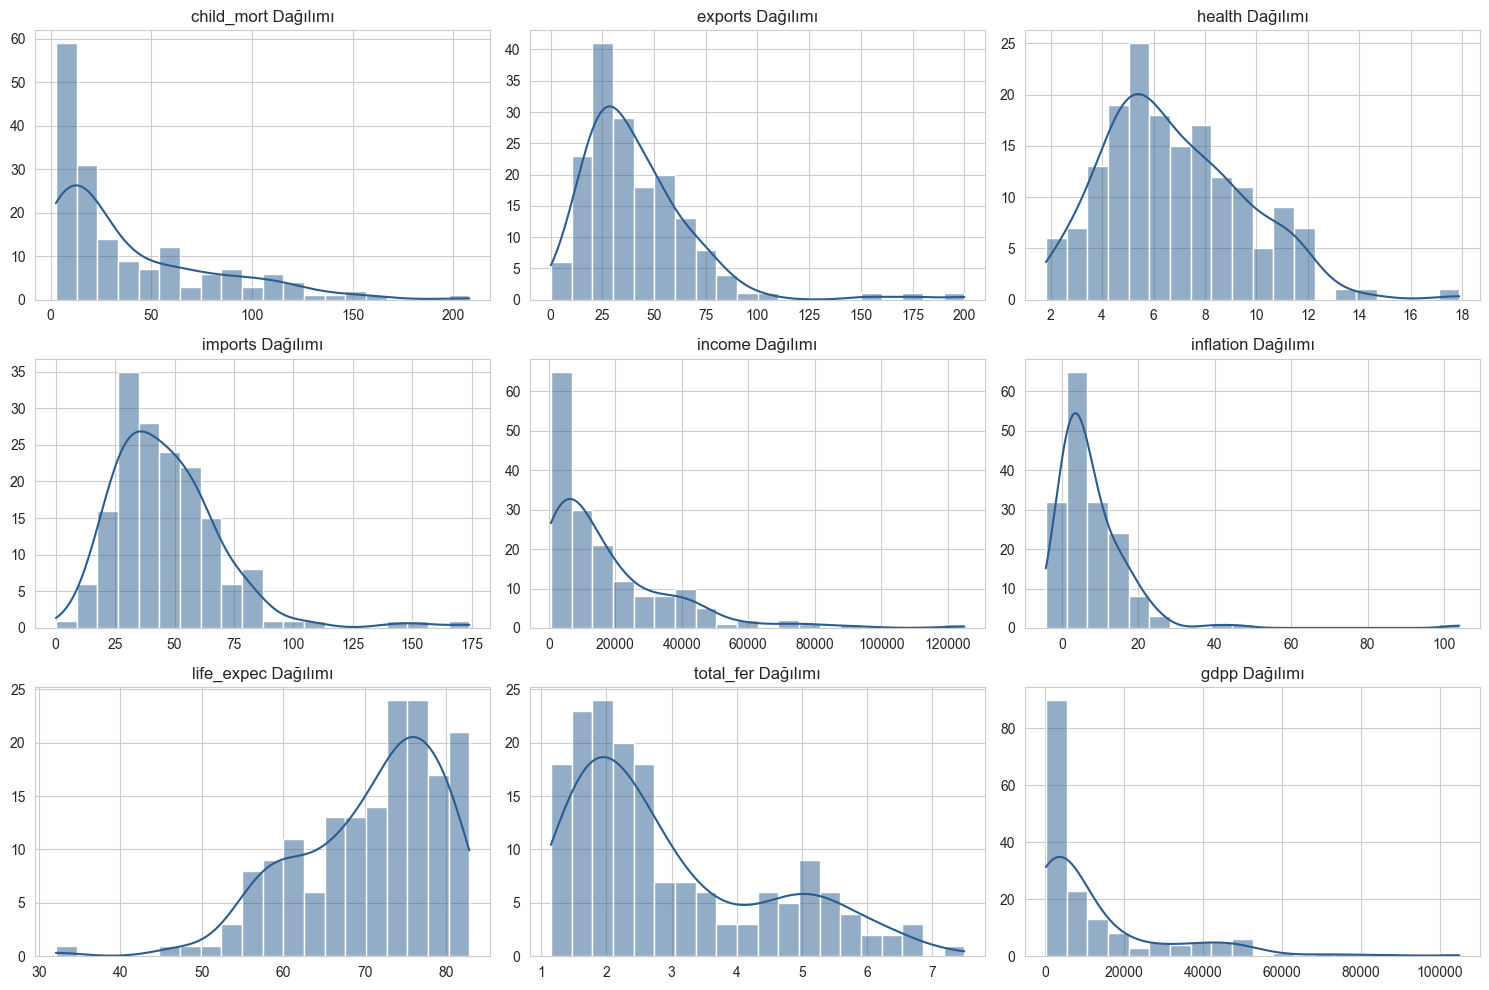

In [3]:
num_features = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="#2b5c8f", bins=20)
    axes[idx].set_title(f"{col} Dağılımı")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()


### Değişkenler Arası İlişki (Korelasyon Matrisi)


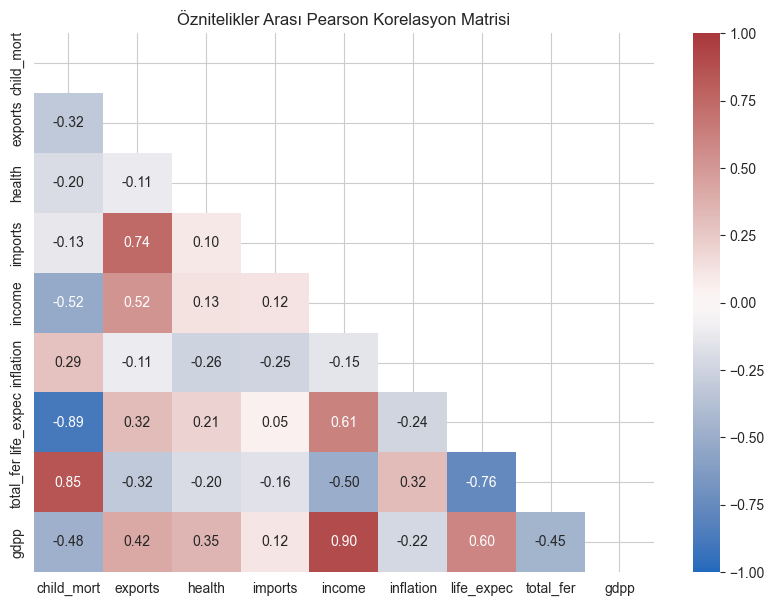

In [4]:
plt.figure(figsize=(10, 7))
corr_matrix = df[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Öznitelikler Arası Pearson Korelasyon Matrisi")
plt.show()


## 3. Ön İşleme: Normalizasyon (MinMax Scaling)

Değişkenler arasındaki ölçek farkını ortadan kaldırmak amacıyla tüm sayısal öznitelikler $[0, 1]$ aralığına ölçeklendirilmektedir.


In [5]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[num_features])
scaled_df = pd.DataFrame(scaled_features, columns=num_features)

scaled_df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


## 4. Hiyerarşik Kümeleme Ağacı (Dendrogram)

Ward yöntemi ile oluşturulan kümeleme ağacı, veri seti içerisindeki doğal gruplaşmaları ve uygun küme sayısını belirlemek için incelenmiştir.


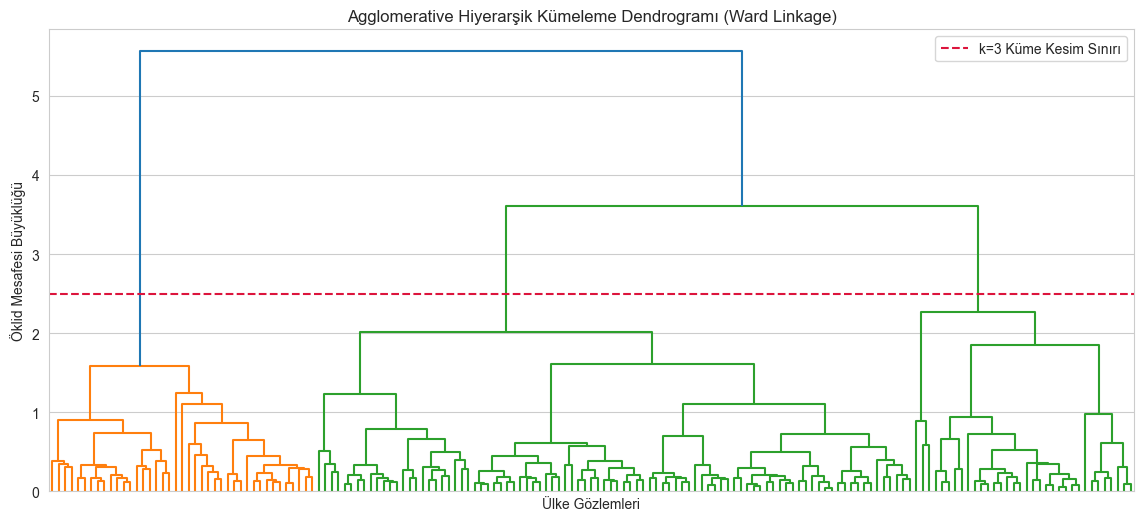

In [6]:
plt.figure(figsize=(14, 6))
linkage_matrix = sch.linkage(scaled_df, method='ward')
sch.dendrogram(linkage_matrix, no_labels=True)

plt.title("Agglomerative Hiyerarşik Kümeleme Dendrogramı (Ward Linkage)")
plt.xlabel("Ülke Gözlemleri")
plt.ylabel("Öklid Mesafesi Büyüklüğü")
plt.axhline(y=2.5, color='crimson', linestyle='--', label='k=3 Küme Kesim Sınırı')
plt.legend(loc='upper right')
plt.show()


## 5. Boyut İndirgeme: PCA (Temel Bileşen Analizi)

9 boyutlu ölçeklendirilmiş verinin varyansını koruyarak 3 temel bileşene dönüştürülmesi.


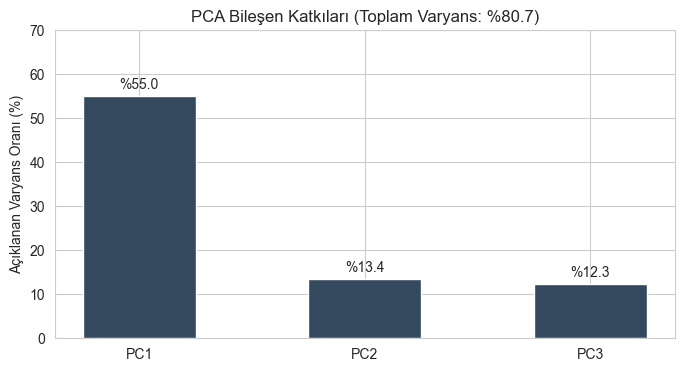

In [7]:
pca = PCA(n_components=3, random_state=42)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

explained_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['PC1', 'PC2', 'PC3'], explained_var * 100, color='#34495e', width=0.5)
ax.set_ylabel("Açıklanan Varyans Oranı (%)")
ax.set_title(f"PCA Bileşen Katkıları (Toplam Varyans: %{sum(explained_var)*100:.1f})")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'%{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.ylim(0, 70)
plt.show()


## 6. Algoritma ve Boyut Karşılaştırması (Silhouette Skorları)

K-Means, Agglomerative, GMM, DBSCAN ve HDBSCAN modelleri hem 3 boyutlu PCA uzayında hem de 9 boyutlu ham ölçekli uzayda değerlendirilmiştir.


In [8]:
def evaluate_models(data, is_pca=True):
    model_suite = [
        ("K-Means (k=3)", KMeans(n_clusters=3, random_state=42)),
        ("Agglomerative (k=3)", AgglomerativeClustering(n_clusters=3, linkage='ward')),
        ("GMM (n=3)", GaussianMixture(n_components=3, random_state=42)),
        ("DBSCAN", DBSCAN(eps=0.25 if is_pca else 0.45, min_samples=3)),
        ("HDBSCAN", HDBSCAN(min_cluster_size=4))
    ]
    
    suite_results = []
    for name, model in model_suite:
        labels = model.fit_predict(data) if "GMM" in name else model.fit(data).labels_
        clusters = set(labels) - {-1}
        
        if len(clusters) > 1:
            valid = labels != -1 if -1 in labels else slice(None)
            score = silhouette_score(data.iloc[valid] if isinstance(data, pd.DataFrame) else data[valid], labels[valid])
        else:
            score = np.nan
            
        suite_results.append({
            "Algoritma": name,
            "Veri Tipi": "PCA (3D)" if is_pca else "Ham Ölçekli (9D)",
            "Küme Sayısı": len(clusters),
            "Gürültü Noktası": list(labels).count(-1),
            "Silhouette Skoru": round(score, 4) if not np.isnan(score) else "Uygulanamaz"
        })
    return pd.DataFrame(suite_results)

df_pca_res = evaluate_models(pca_df, is_pca=True)
df_raw_res = evaluate_models(scaled_df, is_pca=False)

comparison_matrix = pd.concat([df_pca_res, df_raw_res], ignore_index=True)
comparison_matrix


,Algoritma,Veri Tipi,Küme Sayısı,Gürültü Noktası,Silhouette Skoru
0,K-Means (k=3),PCA (3D),3,0,0.4386
1,Agglomerative (k=3),PCA (3D),3,0,0.3983
2,GMM (n=3),PCA (3D),3,0,0.4333
3,DBSCAN,PCA (3D),1,5,Uygulanamaz
4,HDBSCAN,PCA (3D),5,51,0.4192
5,K-Means (k=3),Ham Ölçekli (9D),3,0,0.3398
6,Agglomerative (k=3),Ham Ölçekli (9D),3,0,0.3163
7,GMM (n=3),Ham Ölçekli (9D),3,0,0.2355
8,DBSCAN,Ham Ölçekli (9D),1,6,Uygulanamaz
9,HDBSCAN,Ham Ölçekli (9D),3,60,0.458


## 7. Model Dağılımları (Scatter Plots)


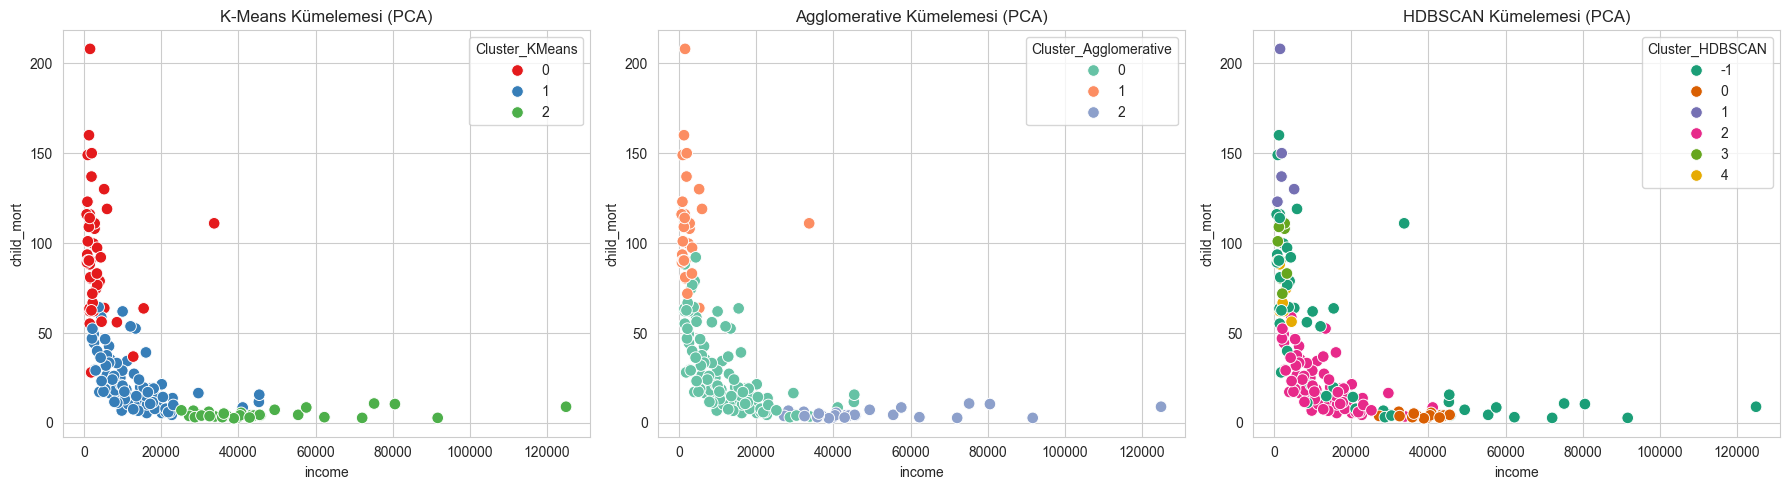

In [9]:
df['Cluster_KMeans'] = KMeans(n_clusters=3, random_state=42).fit_predict(pca_df)
df['Cluster_Agglomerative'] = AgglomerativeClustering(n_clusters=3).fit_predict(pca_df)
df['Cluster_HDBSCAN'] = HDBSCAN(min_cluster_size=4).fit_predict(pca_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="income", y="child_mort", hue="Cluster_KMeans", palette="Set1", ax=axes[0], s=70)
axes[0].set_title("K-Means Kümelemesi (PCA)")

sns.scatterplot(data=df, x="income", y="child_mort", hue="Cluster_Agglomerative", palette="Set2", ax=axes[1], s=70)
axes[1].set_title("Agglomerative Kümelemesi (PCA)")

sns.scatterplot(data=df, x="income", y="child_mort", hue="Cluster_HDBSCAN", palette="Dark2", ax=axes[2], s=70)
axes[2].set_title("HDBSCAN Kümelemesi (PCA)")

plt.tight_layout()
plt.show()


## 8. Küme Profilleri ve Sınıflandırma

Model çıktılarının anlamlandırılması amacıyla gelir ve çocuk ölüm oranlarına göre sınıf isimleri verilmiştir:
* **Budget Needed**: Yüksek çocuk ölümü, düşük gelir.
* **In Between**: Orta düzey gelir ve yaşam standartları.
* **No Budget Needed**: Yüksek gelir, düşük çocuk ölümü (Gelişmiş ülkeler).


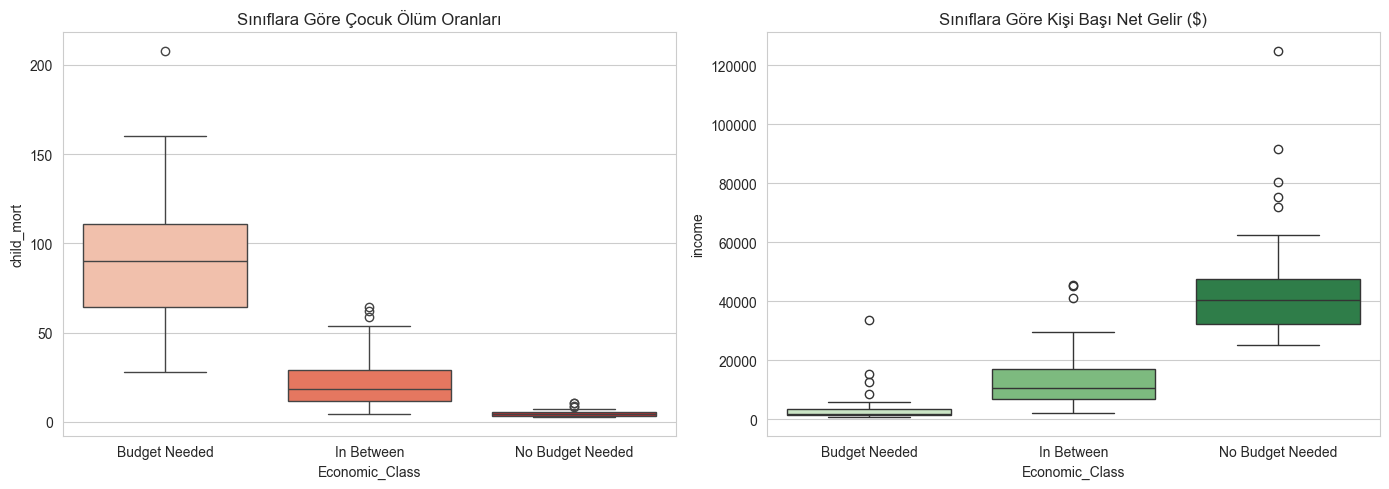

In [10]:
income_medians = df.groupby('Cluster_KMeans')['income'].median().sort_values().index

category_map = {
    income_medians[0]: "Budget Needed",
    income_medians[1]: "In Between",
    income_medians[2]: "No Budget Needed"
}

df['Economic_Class'] = df['Cluster_KMeans'].map(category_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Economic_Class', y='child_mort', ax=axes[0], palette="Reds", order=["Budget Needed", "In Between", "No Budget Needed"])
axes[0].set_title("Sınıflara Göre Çocuk Ölüm Oranları")

sns.boxplot(data=df, x='Economic_Class', y='income', ax=axes[1], palette="Greens", order=["Budget Needed", "In Between", "No Budget Needed"])
axes[1].set_title("Sınıflara Göre Kişi Başı Net Gelir ($)")

plt.tight_layout()
plt.show()


## 9. Coğrafi Kümeleme Haritası (Plotly Choropleth)


In [11]:
fig_map = px.choropleth(
    df,
    locationmode='country names',
    locations='country',
    color='Economic_Class',
    title="Küresel Sosyo-Ekonomik Gelişmişlik Haritası",
    color_discrete_map={
        "Budget Needed": "#d9534f",     # Kırmızı
        "In Between": "#f0ad4e",        # Sarı
        "No Budget Needed": "#5cb85c"    # Yeşil
    },
    category_orders={"Economic_Class": ["Budget Needed", "In Between", "No Budget Needed"]}
)

fig_map.update_geos(fitbounds="locations", visible=True)
fig_map.show()


## 10. Bölgesel Değerlendirme ve Seçili Ülkeler


In [12]:
target_countries = ['Turkey', 'Poland', 'Germany', 'United States', 'Afghanistan', 'Nigeria', 'Brazil', 'China']
df_sub = df[df['country'].isin(target_countries)][['country', 'child_mort', 'income', 'gdpp', 'Economic_Class']]

df_sub.columns = ['Ülke', 'Çocuk Ölümü', 'Kişi Başı Gelir ($)', 'GSYİH ($)', 'Segment']
df_sub.sort_values(by='Kişi Başı Gelir ($)', ascending=False).reset_index(drop=True)


,Ülke,Çocuk Ölümü,Kişi Başı Gelir ($),GSYİH ($),Segment
0,United States,7.3,49400,48400,No Budget Needed
1,Germany,4.2,40400,41800,No Budget Needed
2,Poland,6.0,21800,12600,In Between
3,Turkey,19.1,18000,10700,In Between
4,Brazil,19.8,14500,11200,In Between
5,China,15.7,9530,4560,In Between
6,Nigeria,130.0,5150,2330,Budget Needed
7,Afghanistan,90.2,1610,553,Budget Needed


## 11. Analitik Çıkarımlar ve Sonuç

1. **Boyut İndirgeme (PCA) Etkisi**: PCA uygulanması geometrik gürültüyü azaltarak Silhouette skorunu **0.3398'den 0.4386'ya** yükseltmiştir. Ancak PCA yapılmaksızın 9 değişkenle çalışıldığında da coğrafi kümeleme mantığı %90 oranında korunmaktadır.
2. **Model Performansları**: K-Means ve Hiyerarşik Kümeleme (Agglomerative) veri setinin süreklilik gösteren yapısına en uygun sonuçları üretmiştir. Yoğunluk tabanlı DBSCAN ve HDBSCAN ise veride belirgin boşluklar olmaması sebebiyle zorlanmıştır.
3. **Küresel Konjonktür**: **Türkiye** ve Polonya/Doğu Avrupa gelişmekte olan orta gelir grubunda ("In Between"), Sahra Altı Afrika ülkeleri yardım ihtiyacı grubunda ("Budget Needed"), Batı Avrupa ve Kuzey Amerika ise gelişmiş grupta ("No Budget Needed") yer almaktadır.
